In [34]:
#Libraries 
import os
import time
import math
import numpy as np
import pandas as pd
import scipy
import scipy.signal as spsg
from scipy import stats
from scipy.io import loadmat
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cityblock
from data.labels_brain import reorder_matrix

random.seed(42)

### Reading Data

In [10]:
# Read the data
data_path = "C:/Users/diego/Desktop/phase_coherance_consciousness/data"

# Load LSD data
data_LSD = loadmat(os.path.join(data_path, "LSD_TS_FC.mat"))["DataCorrel"].flatten()
num_patients = range(data_LSD["LSD_TS"].shape[0])
LSDACAT = np.hstack([data_LSD["LSD_TS"][i] for i in num_patients])
LSDPCAT = np.hstack([data_LSD["PCB_TS"][i] for i in num_patients])
LSD_Signals = np.hstack((LSDACAT, LSDPCAT))

# Load PSILO data
num_patients = [0,1,2,3,4,6,7,8,9,10,12,13,14]
data_PSILO = loadmat(os.path.join(data_path, "PSILO_TS_FC.mat"))["DataCorrel"].flatten()
PSILOACAT = np.hstack([data_PSILO["TS_Psilo"][i] for i in num_patients])
PSILOPCAT = np.hstack([data_PSILO["TS_PCB"][i] for i in num_patients])
PSILO_Signals = np.hstack((PSILOACAT, PSILOPCAT))

# Load MDMA data
num_patients = [0,1,2,3,4,5,7,8,9,10,11,12,14,15,17,18,19,20]
data_MDMA = loadmat(os.path.join(data_path, "MDMA_TS_FC.mat"))["DataCorrel"].flatten()
MDMACAT = np.hstack([data_MDMA["TS_MDMA2"][i] for i in num_patients])
MPCAT = np.hstack([data_MDMA["TS_PCB2"][i] for i in num_patients])
MDMA_Signals = np.hstack((MDMACAT, MPCAT))

# Load KETA data
data_KETA = loadmat(os.path.join(data_path, "KETA_TS_FC.mat"))["DataCorrel"].flatten()
num_patients = range(data_KETA["KET_TS"].shape[0])
KETACAT = np.hstack([data_KETA["KET_TS"][i] for i in num_patients])
KETPCAT = np.hstack([data_KETA["PCB_TS"][i] for i in num_patients])
KETA_Signals = np.hstack((KETACAT, KETPCAT))

# Load DMT data
data_DMT = loadmat(os.path.join(data_path, "DMT_TS_FC.mat"))["DataCorrelNoRat"].flatten()
num_patients = range(data_DMT["TimeSeriesDMT"].shape[0])
DMTACAT = np.hstack([data_DMT["TimeSeriesDMT"][i] for i in num_patients])
DMTPCAT = np.hstack([data_DMT["TimeSeriesPCB"][i] for i in num_patients])
DMT_Signals = np.hstack((DMTACAT, DMTPCAT))

# Create dictionary
Signals = {
    "LSD": LSD_Signals,
    "PSILO": PSILO_Signals,
    "MDMA": MDMA_Signals,
    "KETA": KETA_Signals,
    "DMT": DMT_Signals
}

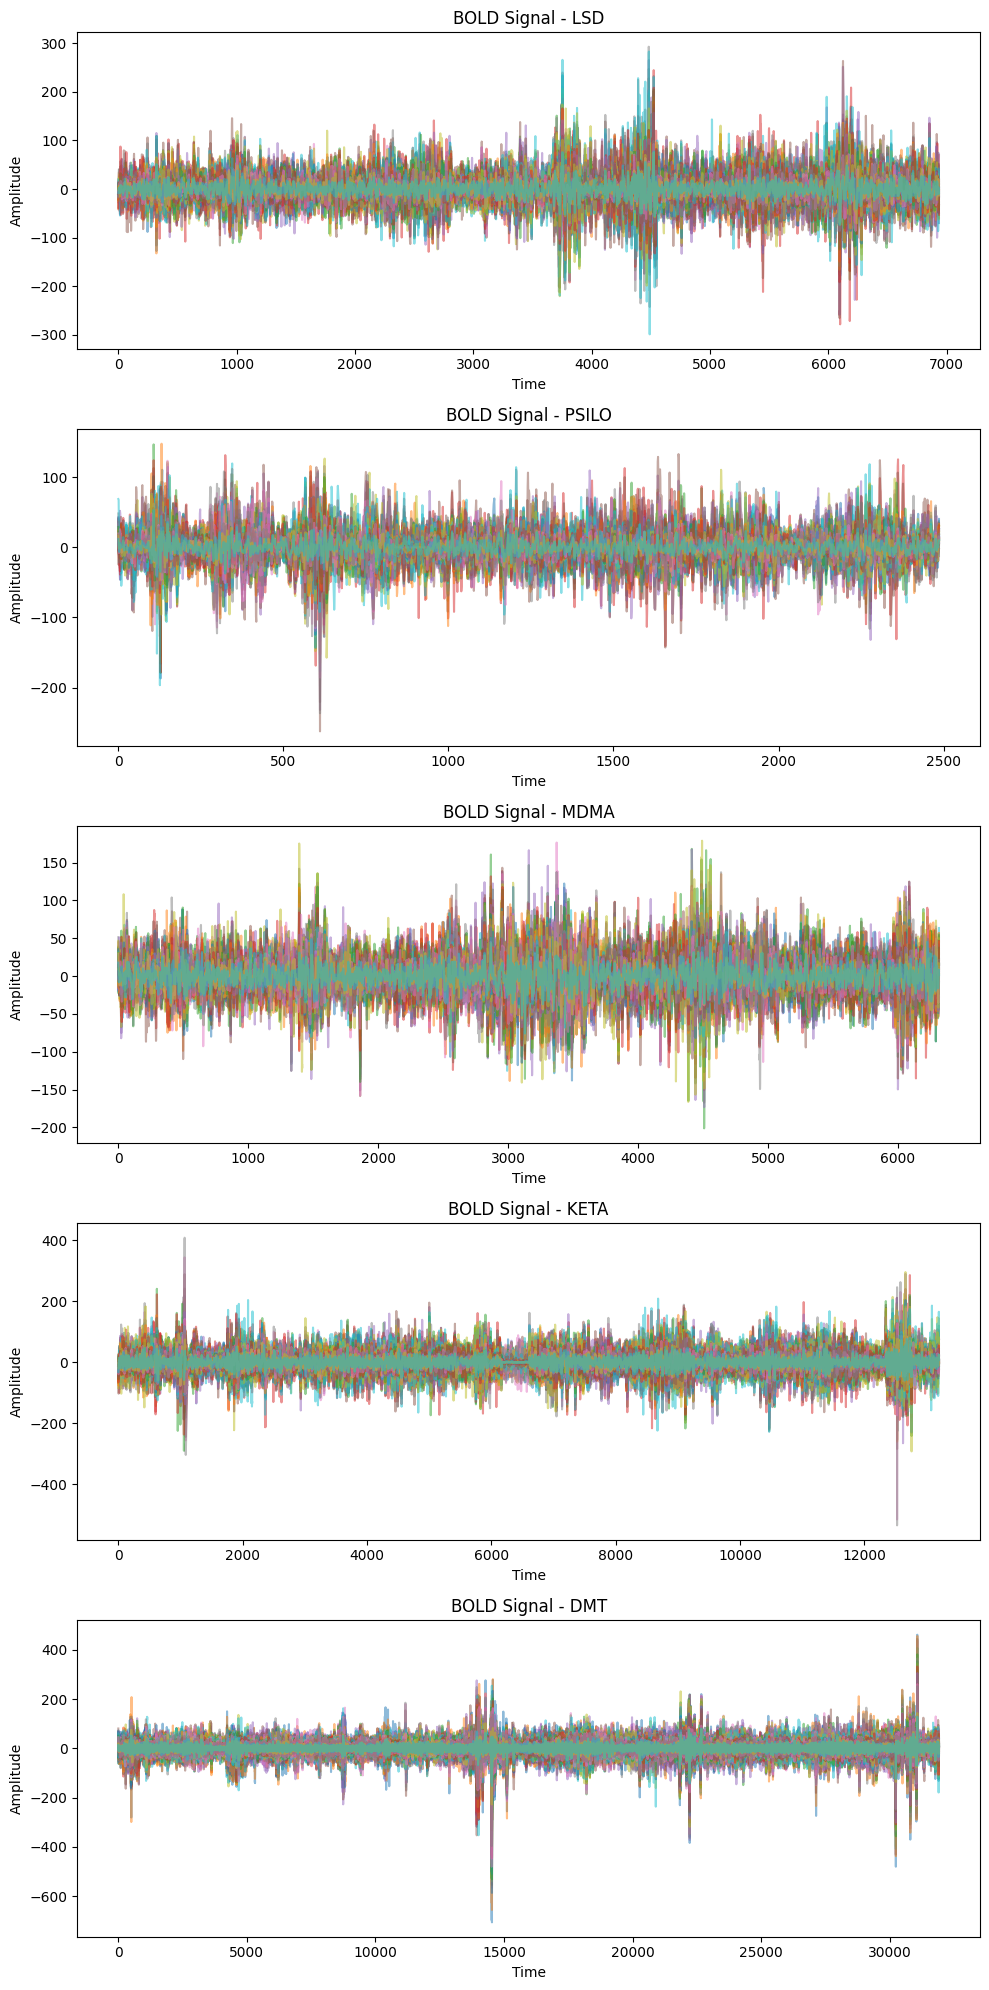

In [11]:
# Plot signals
num_plots = len(Signals)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 4 * num_plots))

if num_plots == 1:
    axes = [axes]

for ax, (key, signal) in zip(axes, Signals.items()):
    ax.plot(signal.T, alpha=0.5)
    ax.set_title(f"BOLD Signal - {key}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


### Extract Size and Features

In [12]:
# Compute number of regions and total time for each signal
time_info = {}
for key, signals_concat in Signals.items():
    ROI, time_length = signals_concat.shape
    Time_per_subj = np.array([len(signals_concat[i]) for i in range(ROI)], dtype=int)
    time_info[key] = (ROI, time_length)
    print(f"{key} - Number of Regions (ROI): {ROI}, Total Time: {time_length}")

LSD - Number of Regions (ROI): 90, Total Time: 6937
PSILO - Number of Regions (ROI): 90, Total Time: 2487
MDMA - Number of Regions (ROI): 90, Total Time: 6316
KETA - Number of Regions (ROI): 90, Total Time: 13202
DMT - Number of Regions (ROI): 90, Total Time: 31918


### Import the Connectoma 

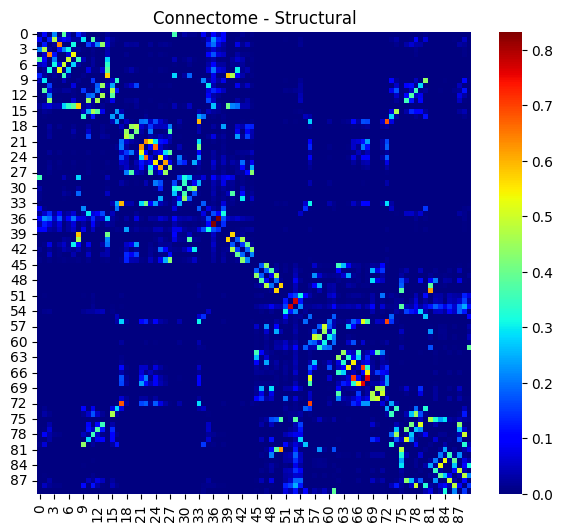

In [35]:
# Import the atlas
data_connectome = os.path.join(data_path, "./structural.mat")
CC = loadmat(data_connectome)['A']

# Plot it
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(CC, cmap='jet',cbar=True, ax=ax)
ax.set_title(f"Connectome - Structural")
plt.show()

In [36]:
CC_reordered, new_labels, new_group_labels = reorder_matrix(connectivity_matrix=CC)
CC_reordered = pd.DataFrame(CC_reordered, index=new_labels, columns=new_labels)
CC_reordered["Group"] = new_group_labels
CC_reordered.head()

,Cingulum_Ant_L,Cingulum_Ant_R,Cingulum_Mid_L,Cingulum_Mid_R,Cingulum_Post_L,Cingulum_Post_R,Frontal_Sup_L,Frontal_Sup_R,Frontal_Sup_Orb_L,Frontal_Sup_Orb_R,...,Temporal_Sup_R,Temporal_Pole_Sup_L,Temporal_Pole_Sup_R,Temporal_Mid_L,Temporal_Mid_R,Temporal_Pole_Mid_L,Temporal_Pole_Mid_R,Temporal_Inf_L,Temporal_Inf_R,Group
Cingulum_Ant_L,0.000000,0.364909,0.447285,0.003396,0.000000,0.000000,0.0,0.002057,0.00000,0.009036,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Ant_R,0.364909,0.000000,0.172070,0.006958,0.000000,0.000000,0.0,0.000000,0.00084,0.021055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Mid_L,0.447285,0.172070,0.000000,0.002129,0.000000,0.000000,0.0,0.000702,0.00039,0.004731,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Mid_R,0.003396,0.006958,0.002129,0.000000,0.178258,0.005520,0.0,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,Cingulate
Cingulum_Post_L,0.000000,0.000000,0.000000,0.178258,0.000000,0.073147,0.0,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007427,0.011651,Cingulate


In [37]:
np.info(CC)

class:  ndarray
shape:  (90, 90)
strides:  (8, 720)
itemsize:  8
aligned:  True
contiguous:  False
fortran:  True
data pointer: 0x247095f14c0
byteorder:  little
byteswap:  False
type: float64


### Preprocess Functions 

In [18]:
# Function to apply a Butterworth bandpass filter to a time series.
# It is particularly useful for removing noise and smoothing the signal in the specified frequency range.
def butterworth_filtering(ts):
    """
    Apply a Butterworth bandpass filter to the input time series `ts`.

    Parameters:
    ts : array-like
        The input time series (1D or 2D array).
        
    Returns:
    filtered_ts : array-like
        The filtered time series, same shape as input.
        
    Notes:
    - The filter settings are dependent on the experimental setup (TR = 2.4 seconds).
    - A 3rd-order Butterworth bandpass filter is applied with cutoff frequencies of 0.01 and 0.2 times the Nyquist frequency.
    - The Nyquist frequency is determined by the repetition time (TR = 2.4s).
    """
    # Parameters
    n_order = 3  # Filter order
    TR = 2.4  # Repetition time (in seconds, relevant for fMRI experiments)
    Nyquist_freq = 0.5 / TR  # Nyquist frequency (half the sampling rate)
    low_f = 0.01 / Nyquist_freq  # Low cutoff frequency (fraction of Nyquist)
    high_f = 0.2 / Nyquist_freq  # High cutoff frequency (fraction of Nyquist)
    
    # Design the Butterworth bandpass filter
    b, a = spsg.iirfilter(n_order, (low_f, high_f), btype='bandpass', ftype='butter', output='ba')
    
    # Apply the filter to the time series using zero-phase filtering
    filtered_ts = spsg.filtfilt(b, a, ts, axis=-1)
    
    return filtered_ts

In [19]:
def adif(a, b):
    """
    Calculate the angular difference between two angles `a` and `b` in radians.

    Parameters:
    a, b : float
        The input angles in radians.
        
    Returns:
    float
        The angular difference between the two angles, always in the range [0, π]. The smallest angel diffence.
    """
    if abs(a - b) > math.pi:
        return 2 * math.pi - abs(a - b)
    else:
        return abs(a - b)


### Phase difference between each pair of regions

In [ ]:
def phase_differences(signals_concat):
    ROI, time_length = signals_concat.shape
    Phases = np.empty((ROI, time_length))

    for i in range(ROI):
        ts = signals_concat[i, :]
        ts_z = stats.zscore(ts)
        ts_z = ts_z - np.mean(ts_z, axis=0)
        ts_filtered = ts_z
        hilbert_tf = spsg.hilbert(ts_z, axis=-1)
        Phases[i, :] = np.angle(hilbert_tf)

    return Phases

#Create a dictionary per each drug of the phase differences
phases = {key: phase_differences(signals) for key, signals in Signals.items()}

### Vectorized Computation for each time instant 

In [28]:
# Function to compute the phase pattern for a given signal

def compute_phase_pattern(phases, ROI, time_length):
    # Number of pairs (only the lower part of the matrix): ROI*(ROI-1)/2
    row_idx, col_idx = np.tril_indices(ROI, k=-1)
    sorted_indices = np.lexsort((row_idx, col_idx))
    lower_indices_corrected = (row_idx[sorted_indices], col_idx[sorted_indices])

    num_pairs = len(lower_indices_corrected[0])
    pattern = np.empty((num_pairs, time_length))

    # Vectorized computation for each time instant
    for t in range(time_length):
        patt = np.empty((ROI, ROI))
        for i in range(ROI):
            for j in range(i):
                patt[i, j] = np.cos(adif(phases[i, t], phases[j, t]))
        pattern[:, t] = patt[lower_indices_corrected]

    return pattern

phase_patterns = {key: compute_phase_pattern(phases[key], *phases[key].shape) for key in phases}

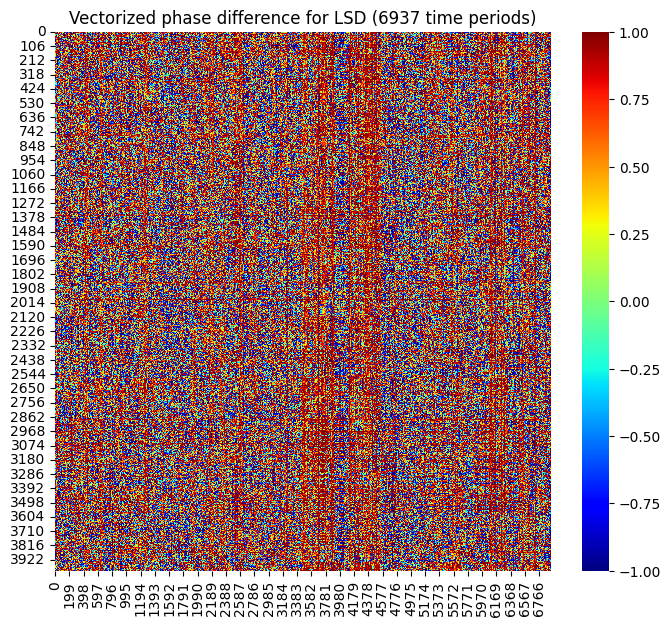

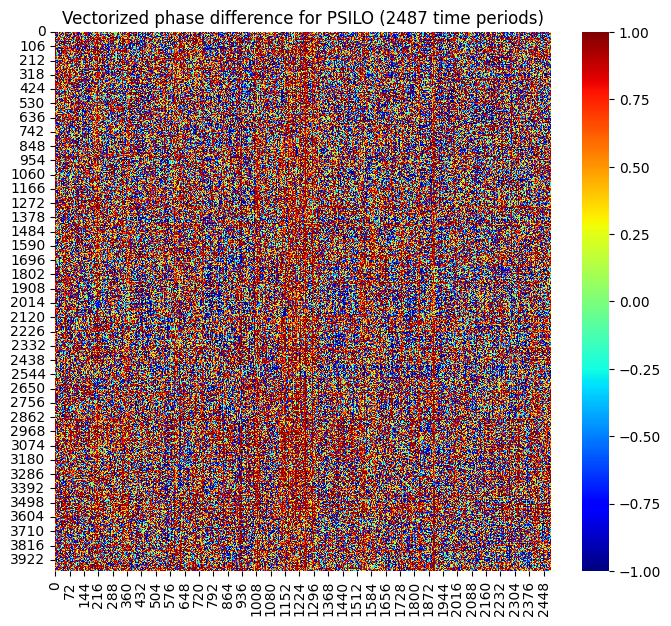

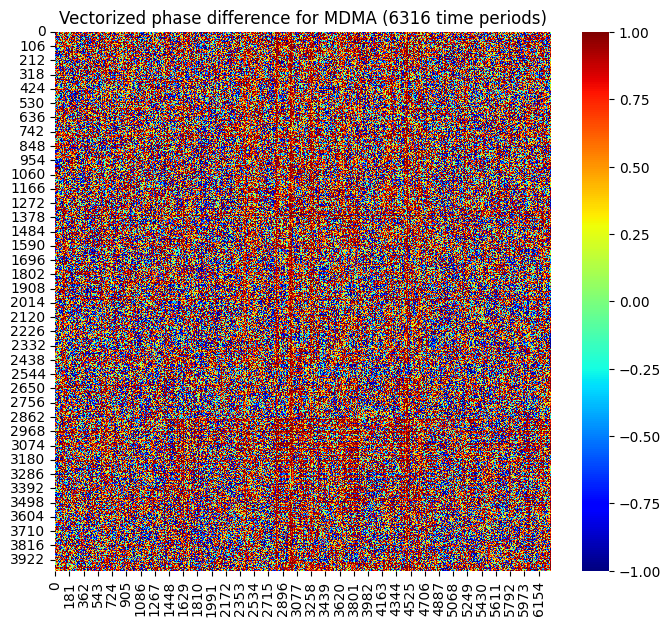

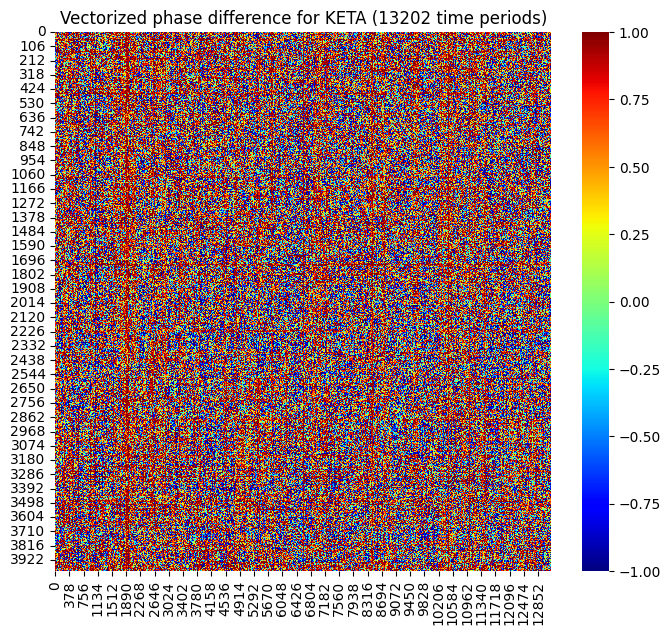

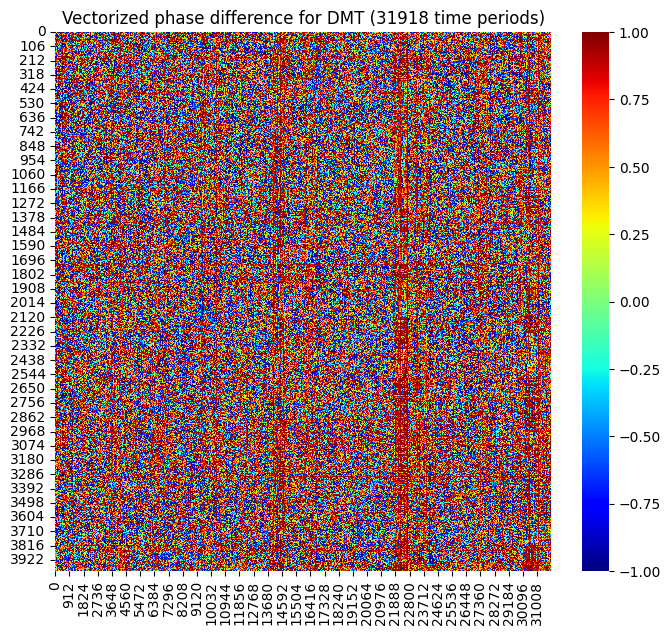

In [29]:
# Loop through the phase patterns dictionary to create the heatmap for each key
for key, pattern in phase_patterns.items():
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(pattern, cmap='jet', vmin=-1, vmax=1, cbar=True, ax=ax)
    ax.set_title(f"Vectorized phase difference for {key} ({pattern.shape[1]} time periods)")
    plt.show()


### K-Means

In [30]:

# Function to compute the Manhattan distance
def compute_manhattan_distance(data_point, centroids, cluster_label):
    return cityblock(data_point, centroids[cluster_label])

# Function for KMeans clustering and distance calculation
def kmeans_clustering(data, k=5, max_iter=200):
    kmeans = KMeans(n_clusters=k, max_iter=max_iter, n_init=1, random_state=0)
    kmeans.fit(data)
    
    cidx = kmeans.labels_  # Cluster indices
    ctrs = kmeans.cluster_centers_  # Cluster centroids
    
    # Compute Manhattan distances
    sum_D = np.sum([compute_manhattan_distance(data[i], ctrs, cidx[i]) for i in range(data.shape[0])])
    
    return cidx, ctrs, sum_D

In [31]:

# Loop over each key in phase_patterns and apply KMeans clustering
KMeans_results = {}

for key, pattern in phase_patterns.items():
    
    # Perform KMeans clustering
    cidx_Pha, ctrs_Pha, sum_D_Pha = kmeans_clustering(pattern.T, k=5)
    
    # Store results in the KMeans_results dictionary
    KMeans_results[key] = {
        "cidx_Pha": cidx_Pha,
        "ctrs_Pha": ctrs_Pha,
        "sum_D_Pha": sum_D_Pha
    }

# Verify the results for one key (e.g., "LSD")
print(f"cidx_Pha shape (LSD): {KMeans_results['LSD']['cidx_Pha'].shape}")
print(f"ctrs_Pha shape (LSD): {KMeans_results['LSD']['ctrs_Pha'].shape}")
print(f"sum_D_Pha (LSD): {KMeans_results['LSD']['sum_D_Pha']}")


cidx_Pha shape (LSD): (6937,)
ctrs_Pha shape (LSD): (5, 4005)
sum_D_Pha (LSD): 15219263.01214531


### Visualizations

In [ ]:
# Clustering States
n_state = 5
cidx = Kmeans_results[n_state]['cidx_Pha'] 
L = cidx.shape[0]
T_shift = 9


id_aal = np.arange(1, 91) 
id_deco = np.concatenate([np.linspace(1, 89, 45, dtype=int), np.linspace(2, 90, 45, dtype=int)[::-1]])
deco_to_aal_mapping = np.searchsorted(id_aal, id_deco)  
CC2 = CC[np.ix_(deco_to_aal_mapping, deco_to_aal_mapping)] 
VC = CC.flatten().astype(np.float64)



# Compute correlations between centroids and connectome
CCA = np.zeros(n_state)
for i in range(n_state):
    centroid_vector = Kmeans_results[n_state]['ctrs_Pha'][i, :]
    QQ = squareform(centroid_vector) 
    VA = QQ.flatten()
    MC = np.corrcoef(VA, VC)  # Correlation with the connectome
    CCA[i] = MC[0, 1]

B = np.sort(CCA)
I = np.argsort(CCA)


rate = np.zeros(n_state)
ratea = np.zeros(n_state)
rateb = np.zeros(n_state)

denom = L - 2 * T_shift 
mid = len(cidx) // 2  #We concatenated 2 time series (drug + placebo)


for bst in range(n_state):
    rate[bst]  = np.sum(cidx == I[bst]) / denom
    ratea[bst] = np.sum(cidx[:mid] == I[bst]) / denom
    rateb[bst] = np.sum(cidx[mid:] == I[bst]) / denom


# Compute cumulative time spent per subject
times_matrix_k = np.zeros((num, 2))
times_matrix_p = np.zeros((num, 2))

for idx, i in enumerate(num_patients):
    size_value_k = data_PSILO[i]['TS_Psilo'].shape[1]
    size_value_p = data_PSILO[i]['TS_PCB'].shape[1]

    times_matrix_k[idx, 0] = size_value_k
    times_matrix_p[idx, 0] = size_value_p

    times_matrix_k[idx, 1] = size_value_k if idx == 0 else times_matrix_k[idx-1, 1] + size_value_k
    times_matrix_p[idx, 1] = size_value_p if idx == 0 else times_matrix_p[idx-1, 1] + size_value_p

scratekt = np.zeros((num, n_state))
scratektp = np.zeros((num, n_state))

for s in range(num):
    for j in range(n_state):
        if s == 0:
            scratekt[s, j] = np.sum(cidx[:int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226:1226 + int(times_matrix_p[s, 1])] == I[j]) / times_matrix_p[s, 1]
        else:
            scratekt[s, j] = np.sum(cidx[int(times_matrix_k[s-1, 1]):int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226 + int(times_matrix_p[s-1, 1]): 1226 + int(times_matrix_p[s, 1]) - 20] == I[j]) / times_matrix_p[s, 1]


CH = np.zeros((num * 2, n_state))

for i in range(n_state):
    CH[:, i] = np.concatenate([scratekt[:, i], scratektp[:, i]])

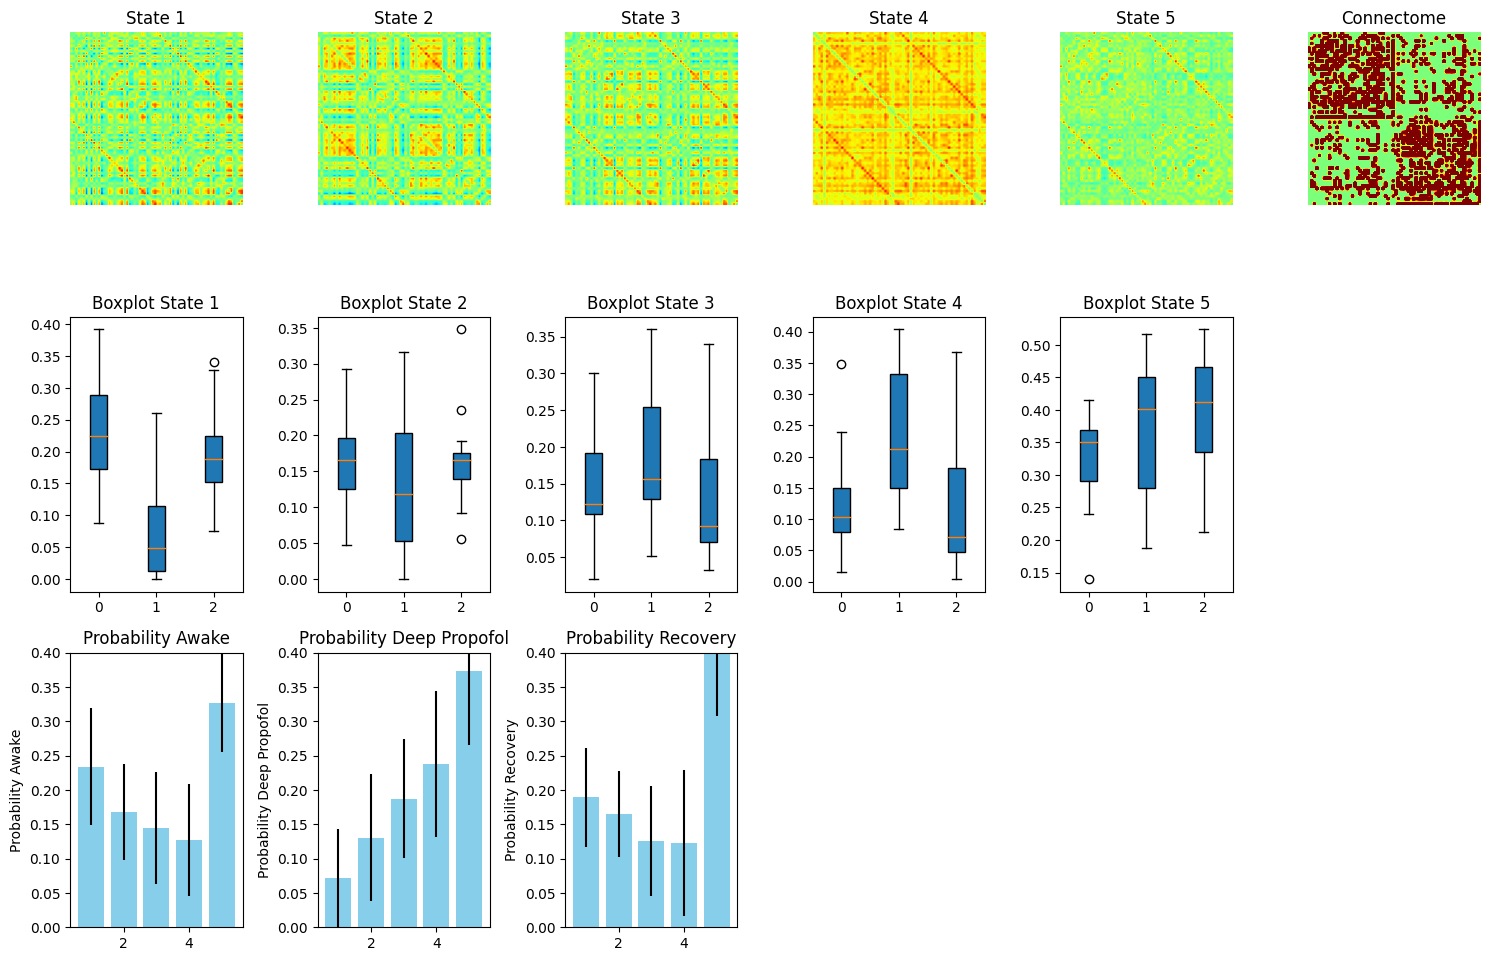

In [ ]:
fig, axs = plt.subplots(3, n_state + 1, figsize=(4*(n_state+1), 12))

#Correlation matrices of each state

for i in range(n_state):
    QQ = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    labels = reorder_matrix(QQ)[2] 
    unique_labels, indices = np.unique(labels, return_index=True)
    centers = [(indices[j] + (indices[j+1] if j+1 < len(indices) else len(labels))) / 2 for j in range(len(indices))]
    im = axs[0, i].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
    axs[0, i].set_title(f"State {i+1} SFC {B[i]:.3f}")
    axs[0,i].set_yticks(centers)
    axs[0,i].set_yticklabels(unique_labels)
    axs[0,i].tick_params(axis="y", labelright=True, labelleft=False)
    axs[0,i].set_xticks([]) 
    axs[0,i].tick_params(axis="x", which="both", bottom=False, top=False)  

#Connectome matrix
axs[0, n_state].imshow(CC, vmin=-1, vmax=1, cmap='jet')
axs[0, n_state].set_title("Connectome")
axs[0, n_state].axis("off")
plt.colorbar(im, ax=axs[0, n_state], shrink=0.6)

#Boxplots for each state
for i in range(n_state):
    axs[1, i].boxplot([CH[:num, i], CH[num:, i]], labels=["PSILO", "PLACEBO"])
    axs[1, i].set_title(f"Boxplot state {i+1}")
axs[1, n_state].axis('off')

#Bar plots for state probabilities in MDMA and PLACEBO
axs[2, 0].bar(np.arange(1, n_state+1), ratea/np.sum(ratea), color='blue', alpha=0.7)
axs[2, 0].set_ylim([0, 0.5])
axs[2, 0].set_ylabel('Probability PSILO')

axs[2, 1].bar(np.arange(1, n_state+1), rateb/np.sum(rateb), color='red', alpha=0.7)
axs[2, 1].set_ylim([0, 0.5])
axs[2, 1].set_ylabel('Probability PLACEBO')


# Hide remaining columns
for j in range(2, n_state+1):
    axs[2, j].axis('off')

plt.tight_layout()
plt.show()
